# Grid Search Backtest — NIFTY Weekly Options

**Strategies:** Bear Call Spread, Bull Put Spread, Batman, Iron Condor  
**Grid:** DTE ∈ {0,1,2,3,4} × SL ∈ {50%,75%,100%,125%,150%} × TP ∈ {25%,50%,75%,100%}  
**Period:** Jan 2024 – Mar 2026 | Merged dataset (09:15–09:20 removed) | Entry 09:21 | Exit 15:20  
**Realism:** Slip Rs2/unit/leg (round-trip) · margin-based lot sizing · monthly compounding · broker charges · No DD pause  
**Fix:** VALID_ENTRY_WDAYS removed — entry date = expiry − DTE business days (handles NSE Thu→Tue expiry change from 2025-09-02)

### Run order
1. **Cell 2** Config  
2. **Cell 3** Unit tests — ALL must print PASS before continuing  
3. **Cell 4** Imports  
4. **Cell 5** Data loaders  
5. **Cell 6** Calendar & ATM  
6. **Cell 7** Engine functions  
7. **Cell 8** Grid search (heavy first run; cached after)  
8. **Cell 9** Results table  
9. **Cell 10** Heatmaps

In [50]:
from pathlib import Path
from datetime import date, timedelta

_NB   = Path('.').resolve()       # backtest_notebooks/
_ROOT = _NB.parent.parent         # market-research/

MERGE_DIR = _ROOT / 'merged'
MERGE_OLD = MERGE_DIR / 'old_format'
MERGE_NEW = MERGE_DIR / 'expiry_wise'
KITE_DIR  = _ROOT / 'gap_trading' / 'kite_minute_cache'
CACHE_DIR = _NB / 'gs_cache'
CACHE_DIR.mkdir(exist_ok=True)

STARTING_CAPITAL  = 100_000
SLIP_PER_UNIT     = 1.0       # Rs per unit per leg (x2 round-trip applied in simulate)
MARGIN_BUF        = 2.0       # margin safety multiplier for lot sizing
LOT_SIZE          = 75
STRIKE_STEP       = 50
ENTRY_TIME        = '09:21'   # first bar in merged data (09:15-09:20 removed for quality)
EXIT_TIME         = '15:20'

SPREAD_W    = 4   # Bear/Bull spread width in strike steps (= 200 pts)
BAT_MID_W   = 3
BAT_OUTER_W = 6
BAT_FAR_W   = 10
IC_SELL_WIDTH = 2   # IC steps from ATM to short legs (2 = sell 100 pts OTM)
IC_BUY_WIDTH  = 6   # IC steps from ATM to wing legs (= 300 pts)

SPAN = {
    'Bear Call Spread': 25_000, 'Bull Put Spread': 25_000,
    'Batman':           90_000, 'Iron Condor':     25_000,
}
MAX_LOTS = {
    'Bear Call Spread': 5, 'Bull Put Spread': 5,
    'Batman':           1, 'Iron Condor':     5,
}

TUESDAY_EXPIRY_START = date(2025, 9, 2)  # NSE switched Thu->Tue expiry on this date
FORCE_RECOMPUTE      = False              # True: delete stale pkl caches; recompute all series

DTE_GRID = [0, 1, 2, 3, 4]
SL_GRID  = [0.50, 0.75, 1.00, 1.25, 1.50]   # fraction of max_loss to trigger SL
TP_GRID  = [0.25, 0.50, 0.75, 1.00]          # fraction of |net_credit| to trigger TP

NSE_HOLIDAYS = {
    date(2024,  1, 22), date(2024,  3, 25), date(2024,  3, 29), date(2024,  4, 14),
    date(2024,  4, 17), date(2024,  5, 23), date(2024,  6, 17), date(2024,  7, 17),
    date(2024,  8, 15), date(2024, 10,  2), date(2024, 10, 24), date(2024, 11,  1),
    date(2024, 11, 15), date(2024, 12, 25),
    date(2025,  2, 26), date(2025,  3, 14), date(2025,  3, 31), date(2025,  4, 10),
    date(2025,  4, 14), date(2025,  4, 18), date(2025,  5,  1), date(2025,  8, 15),
    date(2025,  8, 27), date(2025, 10,  2), date(2025, 10, 21), date(2025, 10, 22),
    date(2025, 11,  5), date(2025, 12, 25),
    date(2026,  1, 26), date(2026,  3, 26),
}

n_per_strat = len(DTE_GRID) * len(SL_GRID) * len(TP_GRID)
print('Config loaded.')
print(f'  Grid: {len(DTE_GRID)} DTE x {len(SL_GRID)} SL x {len(TP_GRID)} TP = {n_per_strat} combos/strategy')
print(f'  Total combos: {len(SPAN) * n_per_strat}')
print(f'  Merged data: {MERGE_DIR}')

Config loaded.
  Grid: 5 DTE x 5 SL x 4 TP = 100 combos/strategy
  Total combos: 400
  Merged data: C:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\merged


In [51]:
# Unit tests — ALL must print PASS before running the grid search.
# Tests cover: credit/debit sign, pnl formula direction, SL/TP thresholds,
#              lot sizing, and charges. No sign reversal is possible if these pass.
import sys
import numpy as np
sys.path.insert(0, str(_NB.parent))   # makes 'strategies/' importable

from strategies.bear_call_spread import get_legs as _bcs
from strategies.long_straddle    import get_legs as _straddle
from strategies.strip            import get_legs as _strip
from strategies.batman           import get_legs as _batman


def _nc(legs, px):
    return sum(px[(l.strike, l.right)] * l.lots * LOT_SIZE *
               (1 if l.action == 'SELL' else -1) for l in legs)

def _wt(legs):
    return np.array([(1 if l.action == 'SELL' else -1) * l.lots * LOT_SIZE
                     for l in legs], dtype=float)


# T1 — BCS net credit is positive (SELL higher-priced + BUY lower-priced CE)
legs = _bcs(25000, 50, lots=1, width=4)
nc = _nc(legs, {(25000, 'CE'): 200.0, (25200, 'CE'): 120.0})
assert nc == 6000.0, f'T1 FAIL: expected 6000 got {nc}'
print(f'T1 PASS  BCS nc = +{nc:.0f}  (credit -> positive)')

# T2 — Straddle net debit is negative (BUY CE + BUY PE)
legs = _straddle(25000, 50, lots=1)
nc2 = _nc(legs, {(25000, 'CE'): 200.0, (25000, 'PE'): 180.0})
assert nc2 == -28500.0, f'T2 FAIL: expected -28500 got {nc2}'
print(f'T2 PASS  Straddle nc = {nc2:.0f}  (debit -> negative)')

# T3a — BCS pnl > 0 when premiums decay (sell strategy profits from decay)
legs = _bcs(25000, 50, lots=1, width=4)
ep = {(25000, 'CE'): 200.0, (25200, 'CE'): 120.0}
nc3 = _nc(legs, ep)           # +6000
wt3 = _wt(legs)               # [+75, -75]
px_decay = np.array([150.0, 90.0])
pnl_win  = nc3 - px_decay @ wt3    # 6000 - (150*75 + 90*(-75)) = 6000 - 4500 = +1500
assert pnl_win > 0, f'T3a FAIL: expected >0 got {pnl_win}'
print(f'T3a PASS BCS pnl = +{pnl_win:.0f} on decay  (profit direction correct)')

# T3b — BCS pnl < 0 when spread widens (sold leg rises faster than bought leg)
px_wide  = np.array([260.0, 100.0])
pnl_loss = nc3 - px_wide @ wt3     # 6000 - (260*75 - 100*75) = 6000 - 12000 = -6000
assert pnl_loss < 0, f'T3b FAIL: expected <0 got {pnl_loss}'
print(f'T3b PASS BCS pnl = {pnl_loss:.0f} on spread widening  (loss direction correct)')

# T4a — Straddle pnl > 0 after large move (long options gain value)
legs = _straddle(25000, 50, lots=1)
ep4  = {(25000, 'CE'): 200.0, (25000, 'PE'): 180.0}
nc4  = _nc(legs, ep4)          # -28500
wt4  = _wt(legs)               # [-75, -75]
px_move  = np.array([350.0, 100.0])    # big up move: CE surged
pnl_move = nc4 - px_move @ wt4        # -28500 - (350*(-75) + 100*(-75)) = -28500 + 33750 = +5250
assert pnl_move > 0, f'T4a FAIL: expected >0 got {pnl_move}'
print(f'T4a PASS Straddle pnl = +{pnl_move:.0f} after large move  (profit direction correct)')

# T4b — Straddle pnl < 0 on theta decay (time kills long options)
px_pin   = np.array([150.0, 130.0])
pnl_pin  = nc4 - px_pin @ wt4         # -28500 - (-21000) = -7500
assert pnl_pin < 0, f'T4b FAIL: expected <0 got {pnl_pin}'
print(f'T4b PASS Straddle pnl = {pnl_pin:.0f} on decay  (loss direction correct)')

# T5 — SL/TP threshold directions
sl_t = -1.0 * 9000.0    # SL threshold: fires when pnl drops HERE
tp_t = +0.80 * 6000.0   # TP threshold: fires when pnl rises HERE

arr_sl  = np.array([-9500.0, -10000.0])   # already below sl_t
arr_tp  = np.array([+5000.0, +6000.0])    # already above tp_t
arr_mid = np.array([+1000.0, +2000.0])    # between sl_t and tp_t: no fire

assert np.where(arr_sl <= sl_t)[0].size > 0,  'T5a FAIL: SL should fire'
assert np.where(arr_sl >= tp_t)[0].size == 0, 'T5a FAIL: TP should not fire'
print(f'T5a PASS SL fires  (pnl={arr_sl[0]:.0f} <= sl_t={sl_t:.0f})')

assert np.where(arr_tp >= tp_t)[0].size > 0,  'T5b FAIL: TP should fire'
assert np.where(arr_tp <= sl_t)[0].size == 0, 'T5b FAIL: SL should not fire'
print(f'T5b PASS TP fires  (pnl={arr_tp[0]:.0f} >= tp_t={tp_t:.0f})')

assert np.where(arr_mid <= sl_t)[0].size == 0, 'T5c FAIL: SL should not fire'
assert np.where(arr_mid >= tp_t)[0].size == 0, 'T5c FAIL: TP should not fire'
print(f'T5c PASS Neither fires  (mid pnl={arr_mid[0]:.0f})')

# T6 — Lot sizing: 1L capital, 25k span, 2x buffer -> floor(100k/50k) = 2 lots
lots_test = min(5, max(1, int(100_000 // (25_000 * 2.0))))
assert lots_test == 2, f'T6 FAIL: expected 2 got {lots_test}'
print(f'T6 PASS  lots = {lots_test}  (1L / 25k / 2x = 2)')

# T7 — Charges are positive
nc_t  = 6000.0; xp_t = 4800.0; nl = 2
brok  = 20 * 2 * nl
tv    = abs(nc_t) + abs(xp_t)
stt   = 0.000625 * abs(nc_t)
exc   = 0.00053  * tv
gst   = 0.18 * (brok + exc)
sebi  = (tv / 1e7) * 10
ch    = brok + stt + exc + gst + sebi
assert ch > 0, f'T7 FAIL: charges must be positive, got {ch}'
print(f'T7 PASS  charges = Rs{ch:.2f} > 0')

# T8 — Slippage scales linearly with lots
slip1 = SLIP_PER_UNIT * 2 * LOT_SIZE * 2   # 2 legs, round-trip, 1 lot
slip3 = SLIP_PER_UNIT * 2 * LOT_SIZE * 2 * 3
assert abs(slip3 - 3 * slip1) < 1e-9, 'T8 FAIL: slip not linear'
print(f'T8 PASS  slip 1-lot=Rs{slip1:.0f}  3-lot=Rs{slip3:.0f}  (linear)')

# T9 -- Iron Condor net credit is positive
from strategies.iron_condor import get_legs as _ic
legs = _ic(25000, 50, lots=1, sell_width=2, buy_width=6)
nc9 = _nc(legs, {(25100,'CE'): 120.0, (25300,'CE'): 50.0,
                  (24900,'PE'): 110.0, (24700,'PE'): 45.0})
assert nc9 > 0, 'T9 FAIL: IC nc must be positive, got ' + str(nc9)
print(f'T9 PASS  IC nc = +{nc9:.0f}  (credit -> positive)')

print()
print('ALL 9 TESTS PASSED -- safe to run grid search')

T1 PASS  BCS nc = +6000  (credit -> positive)
T2 PASS  Straddle nc = -28500  (debit -> negative)
T3a PASS BCS pnl = +1500 on decay  (profit direction correct)
T3b PASS BCS pnl = -6000 on spread widening  (loss direction correct)
T4a PASS Straddle pnl = +5250 after large move  (profit direction correct)
T4b PASS Straddle pnl = -7500 on decay  (loss direction correct)
T5a PASS SL fires  (pnl=-9500 <= sl_t=-9000)
T5b PASS TP fires  (pnl=5000 >= tp_t=4800)
T5c PASS Neither fires  (mid pnl=1000)
T6 PASS  lots = 2  (1L / 25k / 2x = 2)
T7 PASS  charges = Rs104.92 > 0
T8 PASS  slip 1-lot=Rs300  3-lot=Rs900  (linear)
T9 PASS  IC nc = +10125  (credit -> positive)

ALL 9 TESTS PASSED -- safe to run grid search


In [52]:
import sys, warnings, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.insert(0, str(_NB.parent))

import strategies.bear_call_spread as bcs_mod
import strategies.bull_put_spread  as bps_mod
import strategies.batman           as batman_mod
import strategies.iron_condor      as ic_mod

STRATS = {
    'Bear Call Spread': bcs_mod,
    'Bull Put Spread':  bps_mod,
    'Batman':           batman_mod,
    'Iron Condor':      ic_mod,
}

_MON       = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
OLD_CUTOFF = date(2024, 11, 1)   # expiry < this -> old merged format


def d2dmy(d):
    return f'{d.day:02d}{_MON[d.month-1]}{str(d.year)[2:]}'


def parse_dmy(s):
    s = s.strip()
    return date(int(s[5:]) + 2000, _MON.index(s[2:5].upper()) + 1, int(s[:2]))


print('Imports done.')

Imports done.


In [53]:
def _load_old(trade_date, expiry_date):
    mon = _MON[trade_date.month - 1]
    fp  = MERGE_OLD / f'2024{mon}' / f'NIFTY-{d2dmy(expiry_date)}-{d2dmy(trade_date)}.csv'
    if not fp.exists():
        return None
    df = pd.read_csv(fp)
    df.columns    = [c.strip() for c in df.columns]
    df['time_str'] = df['datetime'].astype(str).str[:5]
    return df


def _load_new(trade_date, expiry_date):
    exp_dir = MERGE_NEW / expiry_date.strftime('%Y-%m-%d')
    if not exp_dir.exists():
        return None
    exp_str = f'{expiry_date.day:02d}_{_MON[expiry_date.month-1]}_{str(expiry_date.year)[2:]}'
    files   = list(exp_dir.glob(f'NIFTY_*_*_{exp_str}.csv'))
    if not files:
        return None
    dfs = []
    for fp in files:
        parts = fp.stem.split('_')
        try:
            strike = int(parts[1])
            right  = parts[2]
        except (ValueError, IndexError):
            continue
        try:
            df = pd.read_csv(fp, usecols=['timestamp','open','high','low','close','volume','oi'])
        except Exception:
            continue
        df['ts'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)
        day = df[df['ts'].dt.date == trade_date].copy()
        if day.empty:
            continue
        day['time_str']     = day['ts'].dt.strftime('%H:%M')
        day['strike_price'] = strike
        day['right']        = right
        day.rename(columns={'oi': 'open_interest'}, inplace=True)
        dfs.append(day[['time_str','strike_price','right',
                         'open','high','low','close','open_interest','volume']])
    if not dfs:
        return None
    return (pd.concat(dfs)
              .sort_values(['time_str','strike_price','right'])
              .reset_index(drop=True))


def load_opt(trade_date, expiry_date):
    if expiry_date < OLD_CUTOFF:
        return _load_old(trade_date, expiry_date)
    return _load_new(trade_date, expiry_date)


_opt_cache = {}


def load_opt_cached(td, exp):
    k = (td, exp)
    if k not in _opt_cache:
        _opt_cache[k] = load_opt(td, exp)
    return _opt_cache[k]


print('Data loaders ready.')


Data loaders ready.


In [54]:
# Expiry dates: old format from expiry.csv (pre-Oct 2024) + new from folder names
_NEW_CUTOFF = date(2024, 10, 3)


def _expiries_from_csv():
    csv = MERGE_DIR / 'expiry.csv'
    if not csv.exists():
        return []
    raw  = pd.read_csv(csv, header=0)
    out  = []
    for s in raw.iloc[:, 0].dropna().astype(str):
        s = s.strip()
        if len(s) == 7 and s[:2].isdigit():
            try:
                d = parse_dmy(s)
                if d < _NEW_CUTOFF:
                    out.append(d)
            except ValueError:
                pass
    return out


def _expiries_from_folders():
    return [
        date.fromisoformat(f.name)
        for f in MERGE_NEW.iterdir()
        if f.is_dir() and len(f.name) == 10 and f.name[4] == '-'
    ]


all_expiries = sorted(set(_expiries_from_csv() + _expiries_from_folders()))
expiry_dates = [e for e in all_expiries if e.weekday() < 5 and e not in NSE_HOLIDAYS]

# Trading day calendar: every weekday Jan 2024 - Mar 2026 minus holidays
_d = date(2024, 1, 2)
sorted_days  = []
while _d <= date(2026, 3, 31):
    if _d.weekday() < 5 and _d not in NSE_HOLIDAYS:
        sorted_days.append(_d)
    _d += timedelta(days=1)
all_days = set(sorted_days)


def get_n_before(expiry, n):
    try:
        idx = sorted_days.index(expiry)
        return sorted_days[idx - n] if idx >= n else None
    except ValueError:
        return None


def get_window(start, end):
    return [d for d in sorted_days if start <= d <= end]


# Kite 09:25 NIFTY open -> ATM (primary source)
kite_map = {}
if KITE_DIR.exists():
    for fp in sorted(KITE_DIR.glob('minute_256265_*.pkl')):
        with open(fp, 'rb') as fh:
            chunk = pickle.load(fh)
        if chunk.index.tz is not None:
            chunk.index = chunk.index.tz_localize(None)
        for dt, row in chunk.iterrows():
            if dt.strftime('%H:%M') == '09:25':
                kite_map[dt.date()] = float(row['open'])
    print(f'Kite cache loaded: {len(kite_map)} dates with 09:25 NIFTY open')
else:
    print('WARNING: kite_minute_cache not found -- will use option-based ATM fallback only')


def _atm_from_options(opt_df):
    # Put-call parity: ATM is the strike where |CE_open - PE_open| is minimised
    sub    = opt_df[opt_df['time_str'] == ENTRY_TIME]
    ce     = sub[sub['right'] == 'CE'].set_index('strike_price')['open']
    pe     = sub[sub['right'] == 'PE'].set_index('strike_price')['open']
    common = ce.index.intersection(pe.index)
    if common.empty:
        return None
    return int((ce[common] - pe[common]).abs().idxmin())


def get_atm(d, opt_df=None):
    if d in kite_map:
        return round(kite_map[d] / STRIKE_STEP) * STRIKE_STEP
    if opt_df is not None:
        return _atm_from_options(opt_df)
    return None


print(f'Calendar: {len(sorted_days)} trading days | {len(expiry_dates)} valid expiries')
print(f'  Period: {sorted_days[0]} to {sorted_days[-1]}')


Kite cache loaded: 742 dates with 09:25 NIFTY open
Calendar: 557 trading days | 111 valid expiries
  Period: 2024-01-02 to 2026-03-31


In [55]:
def make_legs(sname, atm):
    mod = STRATS[sname]
    if sname == 'Bear Call Spread':
        return mod.get_legs(atm, STRIKE_STEP, lots=1, width=SPREAD_W)
    if sname == 'Bull Put Spread':
        return mod.get_legs(atm, STRIKE_STEP, lots=1, width=SPREAD_W)
    if sname == 'Batman':
        return mod.get_legs(atm, STRIKE_STEP, lots=1,
                            mid_width=BAT_MID_W, outer_width=BAT_OUTER_W, far_width=BAT_FAR_W)
    if sname == 'Iron Condor':
        return mod.get_legs(atm, STRIKE_STEP, lots=1,
                            sell_width=IC_SELL_WIDTH, buy_width=IC_BUY_WIDTH)
    return mod.get_legs(atm, STRIKE_STEP, lots=1)


def compute_max_loss(legs, entry_px):
    strikes = [l.strike for l in legs]
    spots   = np.arange(min(strikes) - 10 * STRIKE_STEP,
                        max(strikes) + 11 * STRIKE_STEP, STRIKE_STEP)
    worst   = 0.0
    for s in spots:
        pnl = 0.0
        for l in legs:
            intr = max(0, s - l.strike) if l.right == 'CE' else max(0, l.strike - s)
            ep   = entry_px[(l.strike, l.right)]
            pnl += ((ep - intr) if l.action == 'SELL' else (intr - ep)) * l.lots * LOT_SIZE
        worst = min(worst, pnl)
    return abs(worst)


def compute_charges(nc, exit_pnl, n_legs):
    brok = 20 * 2 * n_legs           # Rs 20/order, entry + exit, n_legs orders each side
    tv   = abs(nc) + abs(exit_pnl)
    stt  = 0.000625 * abs(nc)        # STT on option sell value
    exc  = 0.00053  * tv             # exchange txn charge
    gst  = 0.18 * (brok + exc)
    sebi = (tv / 1e7) * 10
    return round(brok + stt + exc + gst + sebi, 2)


def precompute_series(sname, dte):
    """
    Build full intraday PnL array for every qualifying expiry.

    pnl_arr = nc - (current_prices @ wt)
      - nc  > 0 for credit strategies (BCS, BPS, Batman)
      - nc  < 0 for debit strategies  (Strip, Straddle)
      - pnl > 0 means position is profitable at that bar
      - pnl < 0 means position is at a loss

    Entry at ENTRY_TIME open.  SL/TP scan runs across all bars in the holding window.
    """
    series = []
    for expiry in expiry_dates:
        td = get_n_before(expiry, dte)
        if td is None or td not in all_days:
            continue

        # Prevent overlapping trades: skip if entry day falls inside a previous expiry cycle
        prev = next((e for e in expiry_dates if e < expiry), None)
        if prev and td <= prev:
            continue


        oe = load_opt_cached(td, expiry)
        if oe is None:
            continue

        atm = get_atm(td, oe)
        if atm is None:
            continue

        legs = make_legs(sname, atm)
        lk   = [(l.strike, l.right) for l in legs]
        wt   = np.array([(1 if l.action == 'SELL' else -1) * l.lots * LOT_SIZE
                         for l in legs], dtype=float)

        es       = oe[oe['time_str'] == ENTRY_TIME]
        entry_px = {}
        skip     = False
        for l in legs:
            row = es[(es['strike_price'] == l.strike) & (es['right'] == l.right)]
            if row.empty:
                skip = True; break
            entry_px[(l.strike, l.right)] = float(row['open'].iloc[0])
        if skip:
            continue

        nc = sum(entry_px[(l.strike, l.right)] * l.lots * LOT_SIZE *
                 (1 if l.action == 'SELL' else -1) for l in legs)
        ml = compute_max_loss(legs, entry_px)

        pnl_vals = []
        for day in get_window(td, expiry):
            od = load_opt_cached(day, expiry)
            if od is None:
                continue
            sub = od[(od['time_str'] >= ENTRY_TIME) & (od['time_str'] <= EXIT_TIME)]
            if sub.empty:
                continue
            piv = sub.pivot_table(index='time_str',
                                  columns=['strike_price', 'right'],
                                  values='open', aggfunc='first')
            if any(k not in piv.columns for k in lk):
                continue
            arr = nc - piv[lk].values @ wt   # pnl > 0 = profit, pnl < 0 = loss
            pnl_vals.extend(arr.tolist())

        if not pnl_vals:
            continue

        # Compute exit PnL at 15:20 on expiry day (used when neither SL nor TP fires)
        ox = load_opt_cached(expiry, expiry)
        expiry_pnl = 0.0
        if ox is not None:
            xs = ox[ox['time_str'] == EXIT_TIME]
            for l in legs:
                row = xs[(xs['strike_price'] == l.strike) & (xs['right'] == l.right)]
                if row.empty:
                    continue
                ep = float(row['open'].iloc[0])
                if l.action == 'SELL':
                    expiry_pnl += (entry_px[(l.strike, l.right)] - ep) * l.lots * LOT_SIZE
                else:
                    expiry_pnl += (ep - entry_px[(l.strike, l.right)]) * l.lots * LOT_SIZE

        series.append(dict(
            trade_date=td, expiry=expiry,
            pnl_arr=np.array(pnl_vals, dtype=float),
            nc=nc, ml=ml, n_legs=len(legs),
            expiry_pnl=expiry_pnl,
        ))
    return series


def apply_sltp(series, sl_pct, tp_pct):
    """
    Apply SL/TP thresholds to precomputed pnl_arr.

    sl_t = -sl_pct * max_loss   (negative; SL fires when pnl drops here)
    tp_t = +tp_pct * |nc|       (positive; TP fires when pnl rises here)

    First trigger wins.  Tie goes to SL (conservative).
    """
    records = []
    for s in series:
        pa   = s['pnl_arr']
        sl_t = -sl_pct * s['ml']
        tp_t =  tp_pct * abs(s['nc'])

        shi = np.where(pa <= sl_t)[0]
        thi = np.where(pa >= tp_t)[0]
        si  = int(shi[0]) if len(shi) else len(pa)
        ti  = int(thi[0]) if len(thi) else len(pa)

        if si == len(pa) and ti == len(pa):
            xp = s['expiry_pnl']
            xr = 'timeout'
        elif si <= ti:
            xp = float(pa[si])
            xr = 'sl'
        else:
            xp = float(pa[ti])
            xr = 'tp'

        ch = compute_charges(s['nc'], xp, s['n_legs'])
        records.append(dict(
            Trade_Date  = s['trade_date'],
            N_Legs      = s['n_legs'],
            NC          = round(s['nc'], 2),
            Gross_PnL   = round(xp, 2),
            Charges     = round(ch, 2),
            Net_PnL     = round(xp - ch, 2),
            Exit        = xr,
        ))
    return pd.DataFrame(records)


def simulate(df, sname):
    """
    Equity simulation with compounding. No DD pause.

    Lots recalculated once per month: min(MAX_LOTS, floor(capital / (span * buffer)))
    Slippage: SLIP_PER_UNIT * n_legs * LOT_SIZE * 2 (round-trip) per lot
    Stops when capital < 1-lot margin (ruined).
    """
    if df.empty:
        return float(STARTING_CAPITAL), pd.DataFrame(), 0.0

    span     = SPAN[sname]
    max_l    = MAX_LOTS[sname]
    n_legs       = int(df['N_Legs'].iloc[0])
    _ref_legs    = make_legs(sname, 24000)                          # leg structure is ATM-independent
    _total_lots  = sum(l.lots for l in _ref_legs)                   # strips/batman have variable lots per leg
    slip_lot     = SLIP_PER_UNIT * _total_lots * LOT_SIZE * 2       # per sim-lot, round-trip
    eff      = span * MARGIN_BUF

    df   = df.sort_values('Trade_Date').reset_index(drop=True)
    cap  = float(STARTING_CAPITAL)
    peak = cap
    month = None
    lots  = 1
    log   = []

    for _, r in df.iterrows():
        if cap < span:      # can't afford even 1 lot -> stop
            break
        d = r['Trade_Date']
        m = (d.year, d.month)
        if m != month:
            lots  = min(max_l, max(1, int(cap // eff)))
            month = m

        gross = float(r['Gross_PnL']) * lots
        ch    = float(r['Charges'])   * lots
        net   = gross - ch - slip_lot * lots
        cap  += net
        peak  = max(peak, cap)
        dd    = (peak - cap) / peak if peak > 0 else 0.0
        log.append({'Trade_Date': d, 'lots': lots,
                    'net_pnl': round(net), 'capital': round(cap), 'dd': round(dd, 4)})

    log_df = pd.DataFrame(log)
    max_dd = float(log_df['dd'].max()) if not log_df.empty else 0.0
    return round(cap, 2), log_df, max_dd


print('Engine ready.')

Engine ready.


In [56]:
# First run: heavy (loads all option data, caches series to gs_cache/).
# Subsequent runs: fast (loads cached series, only re-runs apply_sltp + simulate).
# Set FORCE_RECOMPUTE=True in Config cell to delete stale pkl caches.

gs_results = []
n_total    = len(STRATS) * len(DTE_GRID) * len(SL_GRID) * len(TP_GRID)
t0         = time.time()

for sname in STRATS:
    for dte in DTE_GRID:
        key = sname.replace(' ', '_') + f'_DTE{dte}'
        fp  = CACHE_DIR / f'gs_{key}.pkl'

        if FORCE_RECOMPUTE and fp.exists():
            fp.unlink()
        if fp.exists():
            with open(fp, 'rb') as f:
                series = pickle.load(f)
            print(f'  Loaded  {sname} DTE{dte}: {len(series)} trades (cached)')
        else:
            print(f'  Computing {sname} DTE{dte} ...', end='', flush=True)
            t1     = time.time()
            series = precompute_series(sname, dte)
            with open(fp, 'wb') as f:
                pickle.dump(series, f)
            print(f' {len(series)} trades  ({time.time() - t1:.0f}s)')

        for sl_pct in SL_GRID:
            for tp_pct in TP_GRID:
                df_t          = apply_sltp(series, sl_pct, tp_pct)
                fin, log, mdd = simulate(df_t, sname)
                n_trades      = len(log)
                wins          = int((log['net_pnl'] > 0).sum()) if n_trades else 0
                wr            = wins / n_trades if n_trades else 0.0
                roi           = (fin - STARTING_CAPITAL) / STARTING_CAPITAL * 100
                tp_n          = int((df_t['Exit'] == 'tp').sum())
                sl_n          = int((df_t['Exit'] == 'sl').sum())
                tm_n          = int((df_t['Exit'] == 'timeout').sum())

                gs_results.append(dict(
                    Strategy = sname, DTE = dte, SL = sl_pct, TP = tp_pct,
                    Trades   = n_trades, WinRate = round(wr, 3),
                    TP_n = tp_n, SL_n = sl_n, TM_n = tm_n,
                    MaxDD    = round(mdd, 3),
                    FinalCap = round(fin), ROI = round(roi, 1),
                ))

gs_df = pd.DataFrame(gs_results)
gs_df.to_csv(CACHE_DIR / 'results.csv', index=False)
print(f'\nDone: {len(gs_results)} combos in {time.time() - t0:.0f}s')
print(f'Saved -> {CACHE_DIR / "results.csv"}')

  Loaded  Bear Call Spread DTE0: 110 trades (cached)
  Loaded  Bear Call Spread DTE1: 108 trades (cached)
  Loaded  Bear Call Spread DTE2: 110 trades (cached)
  Loaded  Bear Call Spread DTE3: 108 trades (cached)
  Loaded  Bear Call Spread DTE4: 105 trades (cached)
  Loaded  Bull Put Spread DTE0: 110 trades (cached)
  Loaded  Bull Put Spread DTE1: 108 trades (cached)
  Loaded  Bull Put Spread DTE2: 110 trades (cached)
  Loaded  Bull Put Spread DTE3: 107 trades (cached)
  Loaded  Bull Put Spread DTE4: 105 trades (cached)
  Loaded  Batman DTE0: 109 trades (cached)
  Loaded  Batman DTE1: 107 trades (cached)
  Loaded  Batman DTE2: 107 trades (cached)
  Loaded  Batman DTE3: 106 trades (cached)
  Loaded  Batman DTE4: 103 trades (cached)
  Loaded  Iron Condor DTE0: 109 trades (cached)
  Loaded  Iron Condor DTE1: 107 trades (cached)
  Loaded  Iron Condor DTE2: 109 trades (cached)
  Loaded  Iron Condor DTE3: 107 trades (cached)
  Loaded  Iron Condor DTE4: 104 trades (cached)

Done: 400 combos in

In [57]:
gs_df = pd.read_csv(CACHE_DIR / 'results.csv')

print('=' * 97)
print(f'  TOP 30 by Final Capital  |  Rs{STARTING_CAPITAL:,} start  |  Jan 2024-Mar 2026  |  No DD pause')
print('=' * 97)
hdr = f'  {"#":>3}  {"Strategy":<20} {"DTE":>4}  {"SL":>5}  {"TP":>5}  {"WR":>6}  {"Trades":>7}  {"MaxDD":>6}  {"FinalCap":>12}  {"ROI":>7}'
print(hdr)
print('  ' + '-' * 87)

top = gs_df.sort_values('FinalCap', ascending=False).head(30).reset_index(drop=True)
for i, r in top.iterrows():
    print(f'  {i+1:>3}  {r["Strategy"]:<20} {int(r["DTE"]):>4}  '
          f'{r["SL"]:.0%}  {r["TP"]:.0%}  '
          f'{r["WinRate"]:.1%}  {int(r["Trades"]):>7}  {r["MaxDD"]:.1%}  '
          f'Rs{int(r["FinalCap"]):>9,}  {r["ROI"]:>6.1f}%')

print()
print('=' * 70)
print('  BEST COMBO PER STRATEGY')
print('=' * 70)
best = (gs_df.loc[gs_df.groupby('Strategy')['FinalCap'].idxmax()]
             .sort_values('FinalCap', ascending=False))
for _, r in best.iterrows():
    print(f'  {r["Strategy"]:<20}  DTE{int(r["DTE"])}  SL={r["SL"]:.0%}  TP={r["TP"]:.0%}'
          f'  ->  Rs{int(r["FinalCap"]):,}  ({r["ROI"]:+.1f}%)'
          f'  WR={r["WinRate"]:.1%}  MaxDD={r["MaxDD"]:.1%}')


  TOP 30 by Final Capital  |  Rs100,000 start  |  Jan 2024-Mar 2026  |  No DD pause
    #  Strategy              DTE     SL     TP      WR   Trades   MaxDD      FinalCap      ROI
  ---------------------------------------------------------------------------------------
    1  Bear Call Spread        3  50%  100%  53.7%      108  44.7%  Rs  244,696   144.7%
    2  Bear Call Spread        3  50%  75%  58.3%      108  49.0%  Rs  201,063   101.1%
    3  Bear Call Spread        4  75%  75%  63.8%      105  78.6%  Rs  193,043    93.0%
    4  Bear Call Spread        2  50%  100%  54.5%      110  42.2%  Rs  181,498    81.5%
    5  Bear Call Spread        3  150%  100%  63.0%      108  53.0%  Rs  170,582    70.6%
    6  Bear Call Spread        3  125%  100%  63.0%      108  54.4%  Rs  161,946    61.9%
    7  Bear Call Spread        3  100%  100%  63.0%      108  54.5%  Rs  161,421    61.4%
    8  Bear Call Spread        2  50%  50%  69.1%      110  51.4%  Rs  155,563    55.6%
    9  Bear Call Sp

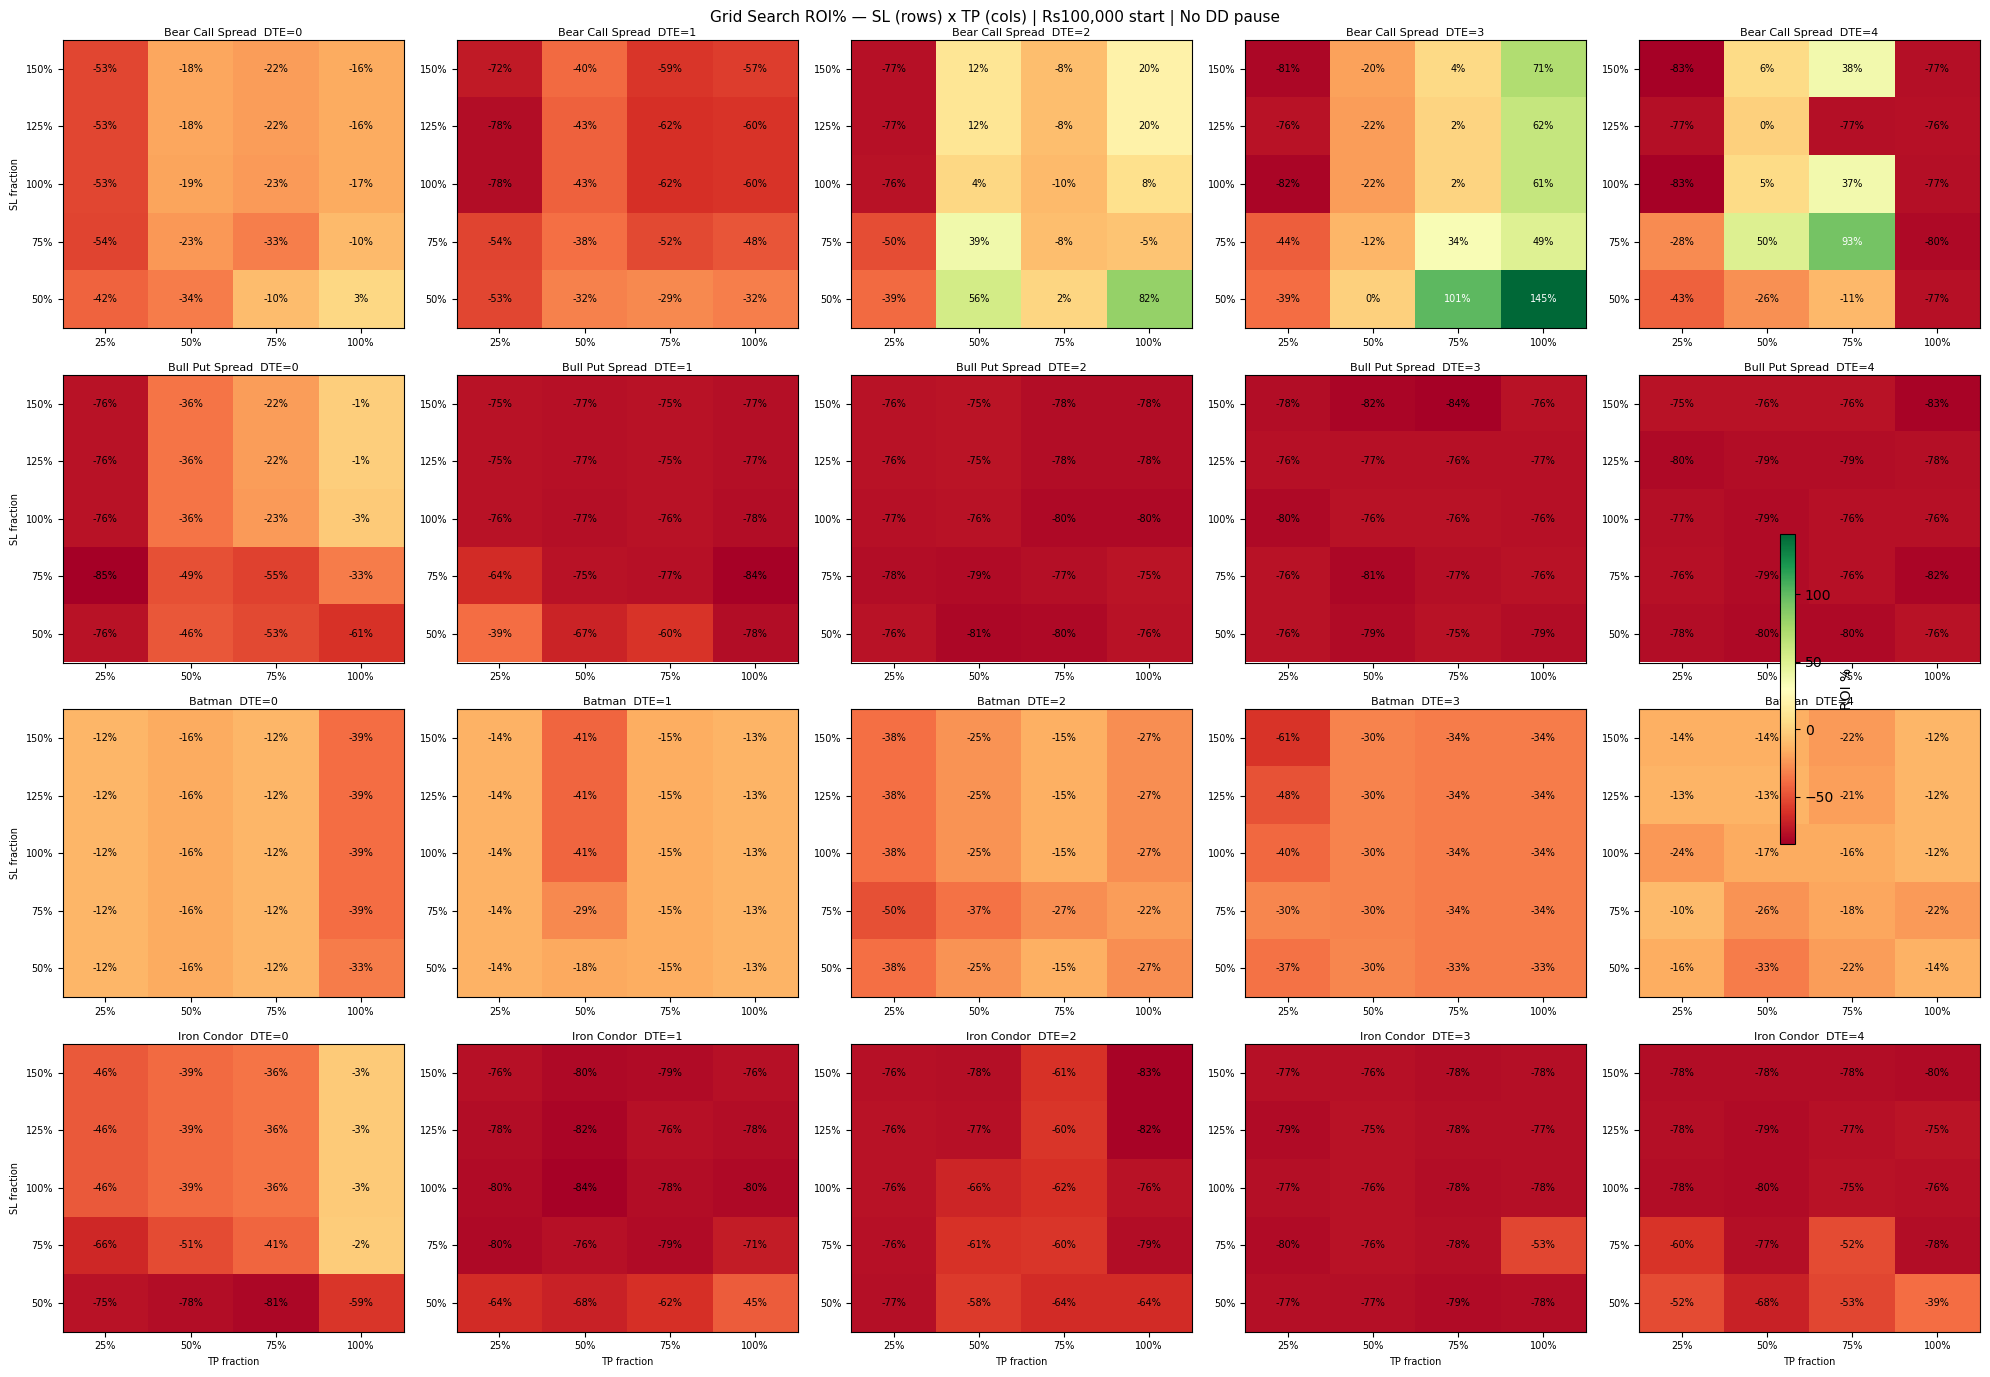

Saved C:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\DTE0_options\backtest_notebooks\gs_cache\heatmap.png


In [58]:
gs_df = pd.read_csv(CACHE_DIR / 'results.csv')

strat_list = list(STRATS.keys())
n_s = len(strat_list)
n_d = len(DTE_GRID)

fig, axes = plt.subplots(n_s, n_d, figsize=(4 * n_d, 3.5 * n_s))

roi_min = gs_df['ROI'].min()
roi_max = gs_df['ROI'].max()

for si, sname in enumerate(strat_list):
    for di, dte in enumerate(DTE_GRID):
        ax  = axes[si, di]
        sub = gs_df[(gs_df['Strategy'] == sname) & (gs_df['DTE'] == dte)]
        if sub.empty:
            ax.axis('off')
            continue

        piv = sub.pivot_table(index='SL', columns='TP', values='ROI', aggfunc='first')
        piv = piv.sort_index(ascending=False)   # highest SL at top

        im = ax.imshow(piv.values, aspect='auto', cmap='RdYlGn',
                       vmin=roi_min, vmax=roi_max)

        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels([f'{v:.0%}' for v in piv.columns], fontsize=7)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f'{v:.0%}' for v in piv.index], fontsize=7)

        for r_i in range(len(piv.index)):
            for c_i in range(len(piv.columns)):
                val   = piv.values[r_i, c_i]
                color = 'white' if abs(val) > 0.6 * max(abs(roi_min), abs(roi_max)) else 'black'
                ax.text(c_i, r_i, f'{val:.0f}%', ha='center', va='center',
                        fontsize=7, color=color)

        ax.set_title(f'{sname}  DTE={dte}', fontsize=8, pad=3)
        if si == n_s - 1:
            ax.set_xlabel('TP fraction', fontsize=7)
        if di == 0:
            ax.set_ylabel('SL fraction', fontsize=7)

plt.colorbar(im, ax=axes, orientation='vertical', fraction=0.01, pad=0.01, label='ROI %')
plt.suptitle(
    f'Grid Search ROI% — SL (rows) x TP (cols) | Rs{STARTING_CAPITAL:,} start | No DD pause',
    fontsize=11)
plt.tight_layout()
out = CACHE_DIR / 'heatmap.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved {out}')
